In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('2017_jun_final - 2017_jun_final.csv')
df.head()

,N,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,...,False,Intermediate (середній),"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,...,False,Pre-intermediate (нище середнього),"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,...,False,Intermediate (середній),"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


In [3]:
df.shape

(8704, 25)

In [4]:
df.dtypes

N                                     int64
Посада                               object
Мова програмування                   object
Спеціалізація                        object
Загальний досвід роботи              object
Досвід роботи на поточному місці     object
Зарплата на місяць                    int64
Зміна зарплати за 12 місяців          int64
Місто                                object
Розмір компанії                      object
Тип компанії                         object
Стать                                object
Вік                                   int64
Освіта                               object
Університет                          object
Ще студент                             bool
Рівень англійської                   object
Предметна область                    object
Дата заповнення                      object
User.Agent                           object
exp                                 float64
current_job_exp                     float64
salary                          

In [5]:
# Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)
nulls_count = df.isnull().sum()
nulls_perc = nulls_count/len(df)*100
pd.DataFrame({'nulls_count':nulls_count, 'nulls_perc_%':nulls_perc.round(1)}).sort_values(by='nulls_count', ascending=False)

,nulls_count,nulls_perc_%
Валюта,8694,99.9
Спеціалізація,7219,82.9
Мова програмування,3850,44.2
cls,1574,18.1
Університет,358,4.1
Предметна область,223,2.6
N,0,0.0
Посада,0,0.0
Загальний досвід роботи,0,0.0
Місто,0,0.0


In [6]:
# Видаліть усі стовпці з пропусками, крім стовпця "Мова програмування"
# Знову порахуйте, яка частка пропусків міститься в кожній колонці і переконайтеся, що залишився тільки стовпець "Мова.програмування"
null_cols = df.columns[nulls_count > 0].drop('Мова програмування')
df = df.drop(columns=null_cols)
nulls = df.isnull().sum()
nulls

N                                      0
Посада                                 0
Мова програмування                  3850
Загальний досвід роботи                0
Досвід роботи на поточному місці       0
Зарплата на місяць                     0
Зміна зарплати за 12 місяців           0
Місто                                  0
Розмір компанії                        0
Тип компанії                           0
Стать                                  0
Вік                                    0
Освіта                                 0
Ще студент                             0
Рівень англійської                     0
Дата заповнення                        0
User.Agent                             0
exp                                    0
current_job_exp                        0
salary                                 0
dtype: int64

In [7]:
# Видаліть усі рядки у вихідній таблиці за допомогою методу dropna
# Визначте новий розмір таблиці за допомогою методу shape
df.dropna(inplace=True)
df.shape

(4854, 20)

In [8]:
# Створіть нову таблицю python_data, в якій будуть тільки рядки зі спеціалістами, які вказали мову програмування Python
# Визначте розмір таблиці python_data за допомогою методу shape

python_data = df[df['Мова програмування']=='Python']
python_data.shape

(207, 20)

In [9]:
# Використовуючи метод groupby, виконайте групування за стовпчиком "Посада"
roles = python_data.groupby('Посада')
roles.size()

Посада
Junior Software Engineer     63
Senior Software Engineer     31
Software Engineer           100
System Architect              2
Technical Lead               11
dtype: int64

In [10]:
#Створіть новий DataFrame, де для згрупованих даних за стовпчиком "Посада", виконайте агрегацію даних за допомогою методу agg і знайдіть мінімальне та максимальне значення у стовпчику "Зарплата.в.місяць"
roles_salary = roles.agg(min_salary = ('Зарплата на місяць', 'min'), max_salary = ('Зарплата на місяць', 'max')).reset_index()
roles_salary

,Посада,min_salary,max_salary
0,Junior Software Engineer,100,1250
1,Senior Software Engineer,1300,9200
2,Software Engineer,500,5400
3,System Architect,3000,5000
4,Technical Lead,1425,6200


In [11]:
#Створіть функцію fill_avg_salary, яка повертатиме середнє значення заробітної плати на місяць. Використовуйте її для методу apply та створіть новий стовпчик "avg"
def fill_avg_salary(row):
    return python_data.loc[python_data['Посада'] == row['Посада'], 'Зарплата на місяць'].mean()
    
python_data = python_data.copy().reset_index()
python_data['avg'] = python_data.apply(fill_avg_salary, axis=1)
python_data.head()

,index,N,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,...,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary,avg
0,12,13,Software Engineer,Python,1,менше 3 місяців,800,200,Київ,до 50 осіб,...,26,Вища,False,Pre-intermediate (нище середнього),12/06/2017 13:05:54,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,1.0,0.0,800,1799.07000
1,68,69,Software Engineer,Python,1.5,0.5,900,900,Київ,до 10 осіб,...,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:11:17,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1.5,0.5,900,1799.07000
2,87,88,Junior Software Engineer,Python,0.5,0.5,600,0,Київ,до 10 осіб,...,19,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:12:25,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,0.5,0.5,600,560.84127
3,114,115,Junior Software Engineer,Python,1.5,0.5,685,250,Київ,до 1000 осіб,...,21,Неповна Вища,False,Intermediate (середній),12/06/2017 13:14:52,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.5,0.5,685,560.84127
4,143,144,Junior Software Engineer,Python,1,1,750,250,Київ,до 10 осіб,...,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 13:19:10,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1.0,1.0,750,560.84127


In [12]:
# Створіть описову статистику за допомогою методу describe для нового стовпчика.
python_data['avg'].describe()

count     207.000000
mean     1753.937198
std       996.562606
min       560.841270
25%       560.841270
50%      1799.070000
75%      1799.070000
max      4000.000000
Name: avg, dtype: float64

In [13]:
python_data.to_csv('python_data.csv', index=False, encoding='utf-8-sig')

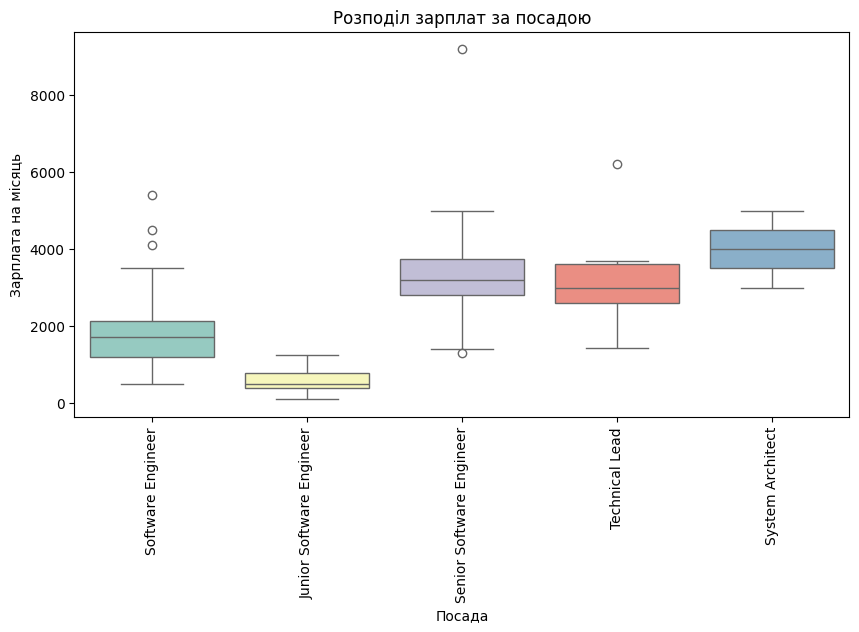

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.figure(figsize=(10,5))

sns.boxplot(data=python_data, x='Посада', y='Зарплата на місяць', hue='Посада', palette="Set3")
plt.title('Розподіл зарплат за посадою')
plt.xlabel('Посада')
plt.xticks(rotation=90)
plt.ylabel('Зарплата на місяць')

plt.show()

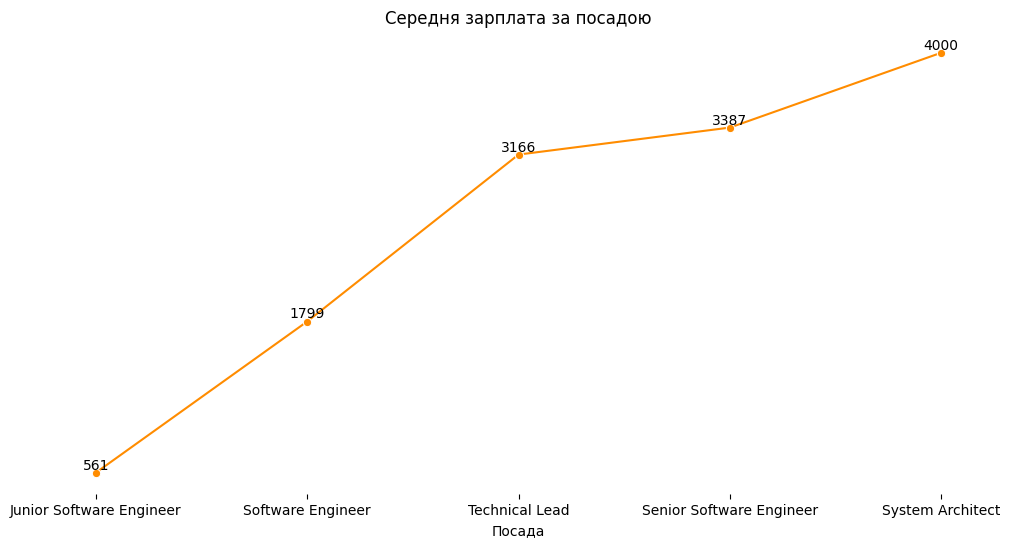

In [15]:
avg_salary = python_data.groupby('Посада')['Зарплата на місяць'].mean().sort_values()

plt.figure(figsize=(12,6))

ax = sns.lineplot(x=avg_salary.index, y=avg_salary.values, marker='o', color='darkorange')
plt.title('Середня зарплата за посадою')
plt.xlabel('Посада')

plt.grid(False)
[ax.text(i, y+30, f'{y:.0f}', ha='center') for i, y in enumerate(avg_salary.values)] # підписи
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_yticks([])

plt.show()

In [16]:
def categorize_experience(x):
    try:
        val = float(x)
    except:
        if x == 'менше 3 місяців':
            return 'до 1 року'
        elif x == '10 і більше років':
            return '5+ років'
        else:
            return 'na'
    if val < 1:
        return 'до 1 року'
    elif 1 <= val < 3:
        return '1-3 роки'
    elif 3 <= val < 5:
        return '3-5 років'
    else:
        return '5+ років'

python_data['Досвід за інтервалом'] = python_data['Досвід роботи на поточному місці'].apply(categorize_experience)
exp = python_data.groupby(['Досвід роботи на поточному місці', 'Досвід за інтервалом']).size()
exp

Досвід роботи на поточному місці  Досвід за інтервалом
0.25                              до 1 року               24
0.5                               до 1 року               42
1                                 1-3 роки                45
1.5                               1-3 роки                21
10 і більше років                 5+ років                 1
2                                 1-3 роки                22
3                                 3-5 років               10
4                                 3-5 років                4
5                                 5+ років                 2
6                                 5+ років                 1
7                                 5+ років                 2
менше 3 місяців                   до 1 року               33
dtype: int64

In [17]:
pivot_table = python_data.pivot_table(
    index='Посада', 
    columns='Досвід за інтервалом', 
    values='Зарплата на місяць',
    aggfunc='mean'
)

pivot_table = pivot_table.fillna(0).astype(int)
exp_order = ['до 1 року', '1-3 роки', '3-5 років', '5+ років']
pivot_table = pivot_table[exp_order]
pivot_table

Досвід за інтервалом,до 1 року,1-3 роки,3-5 років,5+ років
Посада,,,,
Junior Software Engineer,508,701,0,0
Senior Software Engineer,4066,3183,2616,2300
Software Engineer,1688,1843,2025,2025
System Architect,3000,5000,0,0
Technical Lead,4950,2806,3300,2366


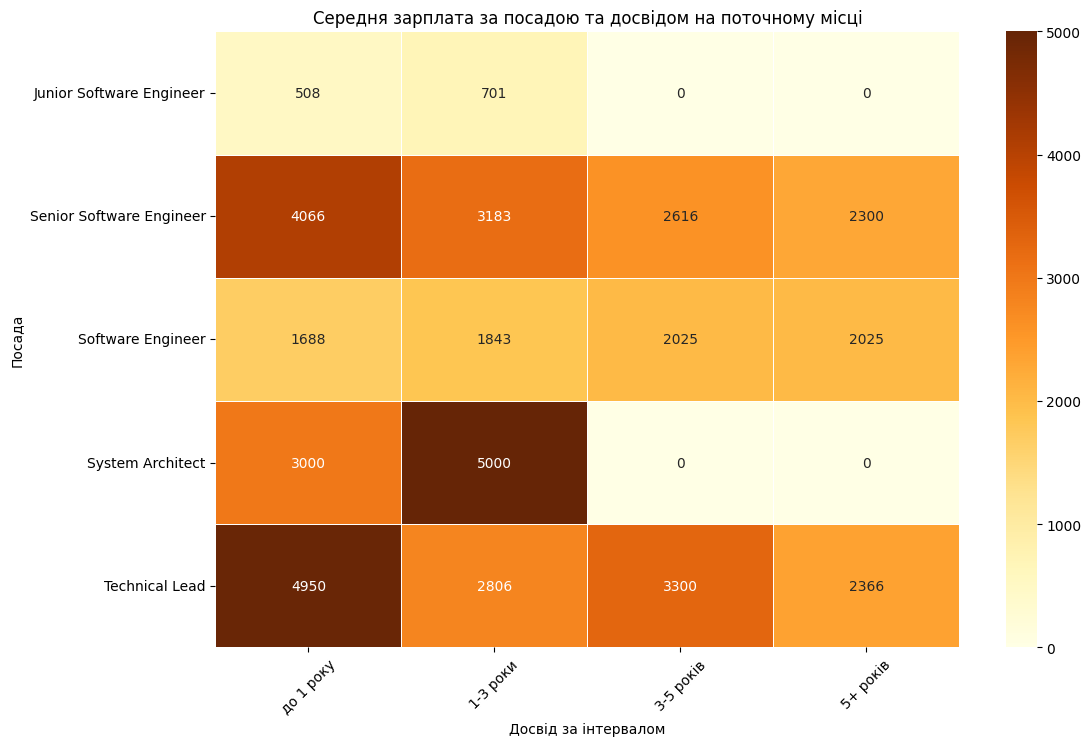

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlOrBr', linewidths=0.5)
plt.title('Середня зарплата за посадою та досвідом на поточному місці')
plt.xlabel('Досвід за інтервалом')
plt.ylabel('Посада')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()